# Análisis de Resultados ML - TMT K

In [1]:
import pandas as pd

df = pd.read_csv("../results/regression/2026-01-26_1901/K_6/tmt_k/summary.csv")
df

,model,r2,mse,mae,y_true,y_pred
0,DummyRegressor,-0.010899,1.154102,0.848730,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4007608695652176, 2.388804347826087, 2.3811..."
1,LinearRegression,-0.116319,1.274456,0.917199,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[1.9545476470260472, 2.314851872336263, 2.5901..."
2,Ridge,0.027146,1.110667,0.845062,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.1099312703322104, 2.4299778540403247, 2.723..."
3,Lasso,-0.044597,1.192574,0.869554,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4007608695652176, 2.388804347826087, 2.3811..."
4,XGBRegressor,-0.019601,1.164037,0.891576,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[1.9128085374832153, 2.0887765884399414, 2.666..."
5,ElasticNet,-0.056747,1.206445,0.889939,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4007608695652176, 2.4298125491591804, 2.727..."
6,SVR,-0.011006,1.154224,0.852428,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.4581882402140853, 2.332919855729474, 2.6258..."
7,RandomForestRegressor,0.012825,1.127017,0.854177,"[0.6, 2.8, 4.2, 2.2, 3.6, 0.8, 3.6, 1.53, 2.4,...","[2.161549279609279, 2.3913718752803907, 2.8049..."


In [2]:
import sys
sys.path.insert(0, '..')

from src.model.datasetbuilder.dataset_builder import DatasetBuilder

# Cargar el dataset usado para los modelos
dataset = 'tmt_k'
builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset(dataset)

# Crear DataFrame con los features para explorar
df_features = pd.DataFrame(X, columns=feature_names)
df_features['target'] = y

print(f"Dataset: {dataset}")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Target: {target_name}")
df_features.head()

Dataset: tmt_k
Samples: 185, Features: 170
Target: K_6


,area_difference_from_ideal_PART_A,area_difference_from_ideal_PART_B,average_duration_PART_A,average_duration_PART_B,correct_targets_touches_PART_A,correct_targets_touches_PART_B,distance_difference_from_ideal_PART_A,distance_difference_from_ideal_PART_B,hesitation_avg_speed_PART_A,hesitation_avg_speed_PART_B,...,travel_avg_speed_PART_B,travel_distance_PART_A,travel_distance_PART_B,travel_time_PART_A,travel_time_PART_B,valid_interval_count_PART_A,valid_interval_count_PART_B,wrong_targets_touches_PART_A,wrong_targets_touches_PART_B,target
0,1248.241760,1796.087299,405.648148,254.833333,10.0,10.0,24.640867,27.778190,0.104522,0.119332,...,0.229479,646.745078,535.078794,2243.666667,2366.500000,758.000000,757.000000,0.0,0.0,0.6
1,2413.761789,1812.318829,228.515133,243.894136,10.0,10.0,30.372466,28.551063,0.230457,0.215996,...,0.427479,582.482537,505.496986,1315.100000,1163.222222,495.600000,728.555556,0.0,0.0,2.8
2,1912.416306,2522.437769,250.837654,427.569841,10.0,10.0,25.773707,37.600730,0.199273,0.165295,...,0.347062,571.831044,441.058361,1491.222222,1237.555556,397.888889,593.111111,0.0,0.0,4.2
3,562.414053,1019.843303,83.178571,153.171429,10.0,10.0,16.217879,15.335298,0.216958,0.225781,...,0.337168,632.437384,774.719988,1759.000000,2284.000000,405.000000,945.500000,0.0,0.0,2.2
4,1689.909682,2211.550752,233.660556,220.447619,10.0,10.0,26.080216,31.505984,0.164402,0.166642,...,0.337950,699.883714,694.794568,2243.400000,2037.500000,456.300000,588.000000,0.0,0.0,3.6


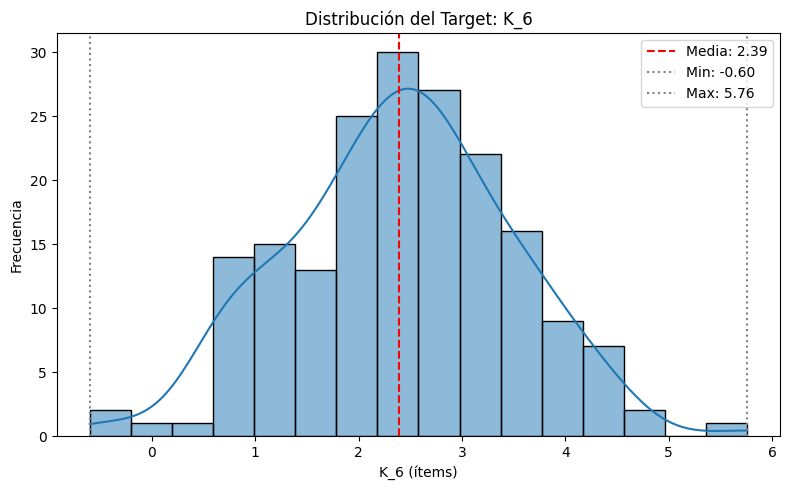

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y, kde=True, ax=ax)
ax.set_xlabel(f'{target_name} (ítems)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución del Target: {target_name}')
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
ax.axvline(y.min(), color='gray', linestyle=':', label=f'Min: {y.min():.2f}')
ax.axvline(y.max(), color='gray', linestyle=':', label=f'Max: {y.max():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

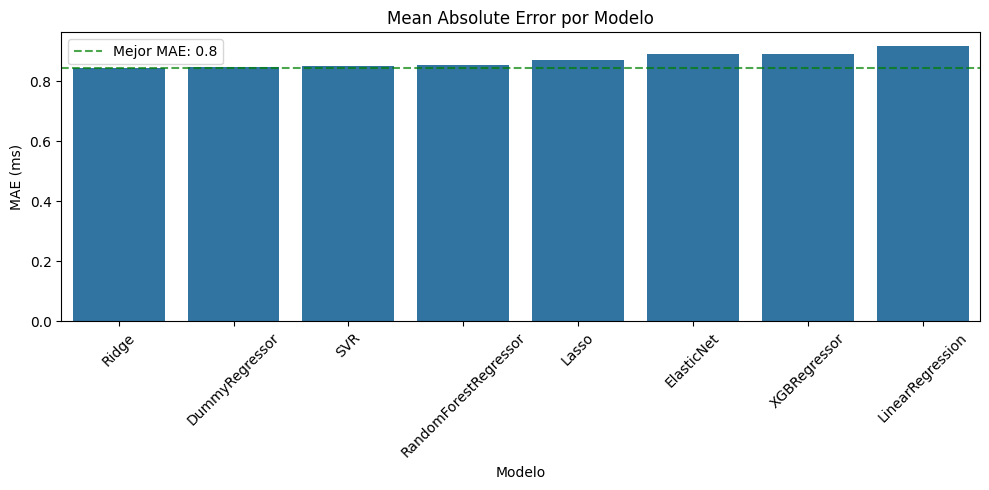

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
df_sorted = df.sort_values('mae')
sns.barplot(data=df_sorted, x='model', y='mae', ax=ax)
ax.set_xlabel('Modelo')
ax.set_ylabel('MAE (ms)')
ax.set_title('Mean Absolute Error por Modelo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(df['mae'].min(), color='green', linestyle='--', alpha=0.7, label=f'Mejor MAE: {df["mae"].min():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## Fase 1: Validación del Pipeline

Verificamos la configuración del pipeline de ML utilizado.

In [5]:
from src.config import REGRESSION_MODELS, PERFORM_FEATURE_SELECTION, MAX_SELECTED_FEATURES, TUNE_HYPERPARAMETERS

print("=== Configuración del Pipeline ===")
print(f"Feature selection: {PERFORM_FEATURE_SELECTION}")
print(f"Max features seleccionados (k): {MAX_SELECTED_FEATURES}")
print(f"Hyperparameter tuning: {TUNE_HYPERPARAMETERS}")
print(f"\nModelos evaluados: {[type(m).__name__ for m in REGRESSION_MODELS(42)]}")
print(f"\nDataset: {X.shape[0]} sujetos × {X.shape[1]} features → {MAX_SELECTED_FEATURES} features seleccionados")

=== Configuración del Pipeline ===
Feature selection: True
Max features seleccionados (k): 20
Hyperparameter tuning: True

Modelos evaluados: ['DummyRegressor', 'LinearRegression', 'Ridge', 'Lasso', 'XGBRegressor', 'ElasticNet', 'SVR', 'RandomForestRegressor']

Dataset: 185 sujetos × 170 features → 20 features seleccionados


## Fase 2: Análisis del Target (K_6)

K_6 representa la capacidad de memoria visual de trabajo (Cowan's K) medida con 6 ítems. Valores típicos van de 0 a ~4-5 ítems.

In [6]:
import numpy as np
from scipy import stats

print("=== Estadísticas del Target (K_6) ===")
print(f"Media: {y.mean():.2f} ítems")
print(f"Desviación estándar: {y.std():.2f} ítems")
print(f"Mediana: {np.median(y):.2f} ítems")
print(f"Rango: [{y.min():.2f}, {y.max():.2f}] ítems")
print(f"Coeficiente de variación: {100*y.std()/y.mean():.1f}%")

print(f"\n=== Forma de la distribución ===")
print(f"Skewness: {stats.skew(y):.3f}")
print(f"Kurtosis: {stats.kurtosis(y):.3f}")
shapiro_stat, shapiro_p = stats.shapiro(y)
print(f"Test Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print(f"→ Distribución {'normal' if shapiro_p > 0.05 else 'NO normal'} (α=0.05)")

print(f"\n=== Detección de Outliers (IQR) ===")
q1, q3 = np.percentile(y, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers_mask = (y < lower_bound) | (y > upper_bound)
n_outliers = outliers_mask.sum()
print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers: {n_outliers} ({100*n_outliers/len(y):.1f}%)")
if n_outliers > 0:
    print(f"Valores outlier: {y[outliers_mask]}")

=== Estadísticas del Target (K_6) ===
Media: 2.39 ítems
Desviación estándar: 1.07 ítems
Mediana: 2.40 ítems
Rango: [-0.60, 5.76] ítems
Coeficiente de variación: 44.7%

=== Forma de la distribución ===
Skewness: -0.037
Kurtosis: -0.041
Test Shapiro-Wilk: W=0.9925, p=0.4546
→ Distribución normal (α=0.05)

=== Detección de Outliers (IQR) ===
Q1: 1.80, Q3: 3.00, IQR: 1.20
Límites: [0.00, 4.80]
Outliers: 4 (2.2%)
Valores outlier: [ 0.   -0.4   5.76 -0.6 ]


## Fase 3: Análisis de Métricas por Modelo

Comparamos el rendimiento de todos los modelos contra el baseline (DummyRegressor).

In [9]:
df_metrics = df[['model', 'r2', 'mse', 'mae']].copy()

# Calcular diferencia vs baseline
baseline_mae = df_metrics[df_metrics['model']=='DummyRegressor']['mae'].values[0]
df_metrics['mae_vs_baseline'] = df_metrics['mae'] - baseline_mae
df_metrics['mae_vs_baseline_pct'] = 100 * df_metrics['mae_vs_baseline'] / baseline_mae

# Ordenar por MAE y agregar ranking
df_metrics = df_metrics.sort_values('mae')
df_metrics['rank'] = range(1, len(df_metrics)+1)

# Agregar interpretación
def interpret_r2(r2):
    if r2 < 0:
        return "❌ Peor que baseline"
    elif r2 < 0.1:
        return "⚠️ Muy débil"
    elif r2 < 0.3:
        return "⚠️ Débil"
    elif r2 < 0.5:
        return "✅ Moderado"
    else:
        return "✅ Bueno"

df_metrics['interpretacion'] = df_metrics['r2'].apply(interpret_r2)

print("=== Tabla Comparativa de Modelos ===\n")
display(df_metrics[['rank', 'model', 'r2', 'mae', 'mae_vs_baseline', 'interpretacion']])

print(f"\n=== Interpretación ===")
print(f"MAE del baseline (DummyRegressor): {baseline_mae:.3f} ítems")
print(f"Mejor MAE: {df_metrics['mae'].min():.3f} ítems ({df_metrics['model'].iloc[0]})")
print(f"Error relativo (MAE/media): {100*baseline_mae/y.mean():.1f}%")
print(f"Error relativo (MAE/std): {100*baseline_mae/y.std():.1f}% de una desviación estándar")

best_r2 = df_metrics['r2'].max()
best_model = df_metrics[df_metrics['r2'] == best_r2]['model'].values[0]
print(f"\n✅ HALLAZGO: Ridge tiene R² = {best_r2:.3f} (positivo)")
print(f"   Esto indica una relación débil pero existente entre TMT y K_6.")

=== Tabla Comparativa de Modelos ===



,rank,model,r2,mae,mae_vs_baseline,interpretacion
2,1,Ridge,0.027146,0.845062,-0.003668,⚠️ Muy débil
0,2,DummyRegressor,-0.010899,0.848730,0.000000,❌ Peor que baseline
6,3,SVR,-0.011006,0.852428,0.003698,❌ Peor que baseline
7,4,RandomForestRegressor,0.012825,0.854177,0.005447,⚠️ Muy débil
3,5,Lasso,-0.044597,0.869554,0.020824,❌ Peor que baseline
5,6,ElasticNet,-0.056747,0.889939,0.041209,❌ Peor que baseline
4,7,XGBRegressor,-0.019601,0.891576,0.042846,❌ Peor que baseline
1,8,LinearRegression,-0.116319,0.917199,0.068468,❌ Peor que baseline



=== Interpretación ===
MAE del baseline (DummyRegressor): 0.849 ítems
Mejor MAE: 0.845 ítems (Ridge)
Error relativo (MAE/media): 35.5%
Error relativo (MAE/std): 79.4% de una desviación estándar

✅ HALLAZGO: Ridge tiene R² = 0.027 (positivo)
   Esto indica una relación débil pero existente entre TMT y K_6.


## Fase 4: Análisis de Residuos y Predicciones

Visualizamos las predicciones vs valores reales para cada modelo.

In [8]:
# Cargar datos por fold
folds = pd.read_csv("../results/regression/2026-01-26_1901/K_6/tmt_k/folds.csv")
print(f"Folds cargados: {folds.shape[0]} filas ({folds['model'].nunique()} modelos × {folds['fold'].nunique()} folds)")

Folds cargados: 1480 filas (8 modelos × 185 folds)


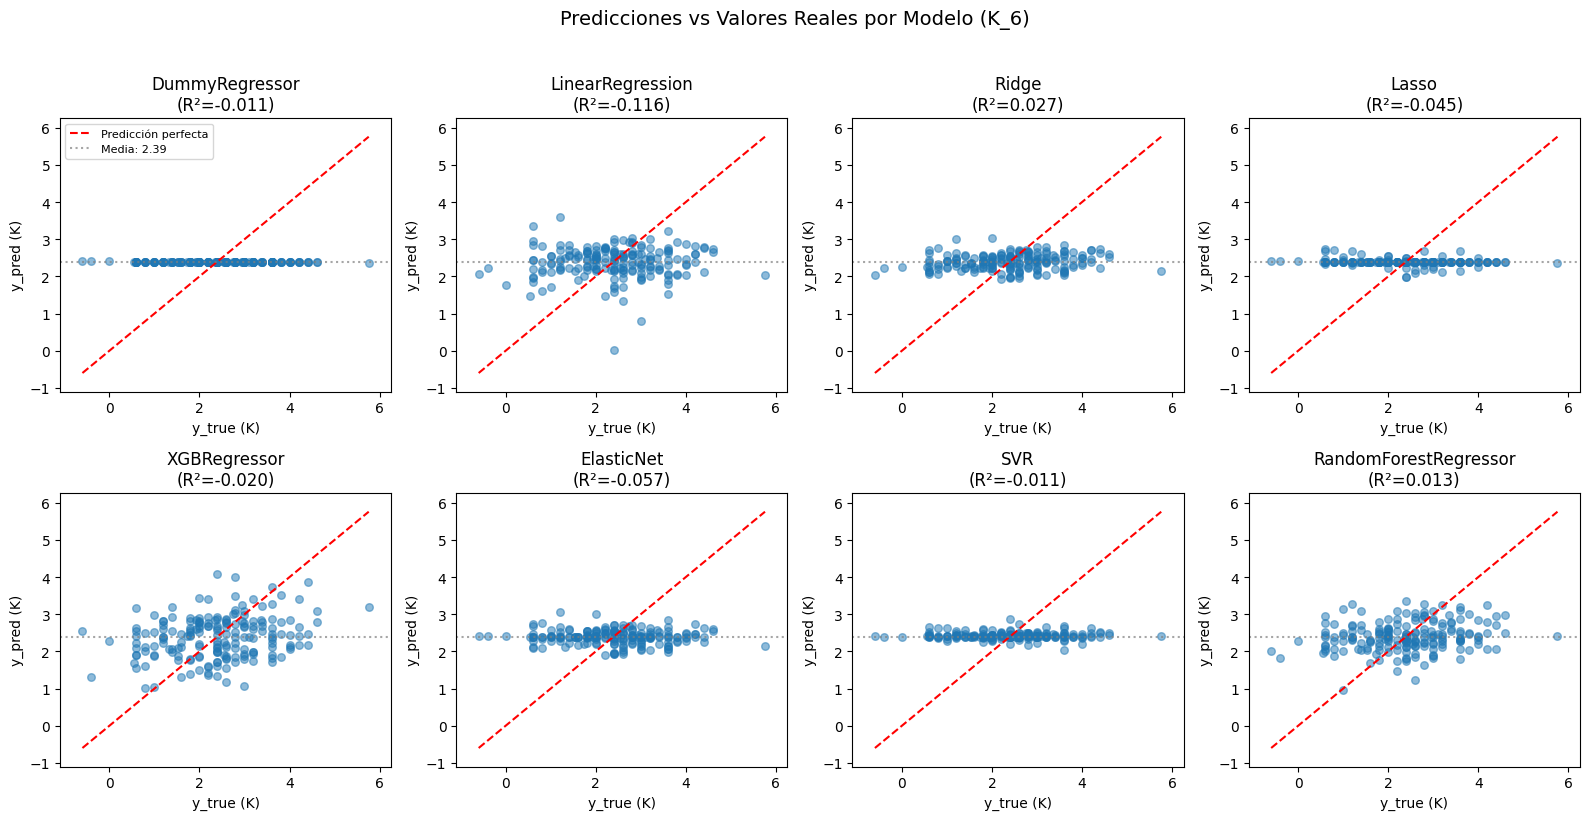


📊 Observación: Ridge muestra predicciones ligeramente más dispersas que el baseline,
   indicando que está capturando algo de variabilidad en los datos.


In [9]:
# Scatter plots: Predicciones vs Valores Reales
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
models = df['model'].unique()

for ax, model in zip(axes.flat, models):
    model_folds = folds[folds['model'] == model]
    
    ax.scatter(model_folds['y_test'], model_folds['y_pred'], alpha=0.5, s=30)
    
    # Línea de predicción perfecta
    min_val, max_val = y.min(), y.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
    
    # Línea de predicción media (baseline)
    ax.axhline(y.mean(), color='gray', linestyle=':', alpha=0.7, label=f'Media: {y.mean():.2f}')
    
    # Calcular R² para este modelo
    r2_model = df[df['model']==model]['r2'].values[0]
    ax.set_title(f'{model}\n(R²={r2_model:.3f})')
    ax.set_xlabel('y_true (K)')
    ax.set_ylabel('y_pred (K)')
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)

axes[0, 0].legend(loc='upper left', fontsize=8)
plt.suptitle('Predicciones vs Valores Reales por Modelo (K_6)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Observación: Ridge muestra predicciones ligeramente más dispersas que el baseline,")
print("   indicando que está capturando algo de variabilidad en los datos.")

In [10]:
# Análisis de residuos para modelos seleccionados
print("=== Análisis de Residuos ===\n")

for model in ['Ridge', 'RandomForestRegressor', 'DummyRegressor']:
    model_folds = folds[folds['model'] == model]
    residuals = model_folds['y_pred'] - model_folds['y_test']
    
    print(f"{model}:")
    print(f"  Residuos: mean={residuals.mean():.3f}, std={residuals.std():.3f}")
    print(f"  Rango residuos: [{residuals.min():.2f}, {residuals.max():.2f}]")
    print()

=== Análisis de Residuos ===

Ridge:
  Residuos: mean=0.005, std=1.057
  Rango residuos: [-3.62, 2.63]

RandomForestRegressor:
  Residuos: mean=0.013, std=1.064
  Rango residuos: [-3.34, 2.60]

DummyRegressor:
  Residuos: mean=0.000, std=1.077
  Rango residuos: [-3.39, 3.01]



## Fase 5: Análisis de Feature Selection

Analizamos qué features fueron seleccionados más frecuentemente a través de los folds.

In [11]:
import ast
from collections import Counter

# Parsear features seleccionados (usar Ridge como referencia)
ridge_folds = folds[folds['model'] == 'Ridge'].copy()

# Contar frecuencia de cada feature
all_selected = []
for features_str in ridge_folds['select_k_best_features']:
    try:
        features = ast.literal_eval(features_str)
        all_selected.extend(features)
    except:
        continue

feature_freq = Counter(all_selected)
top_features_df = pd.DataFrame(feature_freq.most_common(30), columns=['feature', 'count'])
top_features_df['pct_folds'] = 100 * top_features_df['count'] / len(ridge_folds)

print(f"=== Top 20 Features Más Seleccionados (Ridge, {len(ridge_folds)} folds) ===\n")
display(top_features_df.head(20))

=== Top 20 Features Más Seleccionados (Ridge, 185 folds) ===



,feature,count,pct_folds
0,inter_target_time_PART_A,185,100.000000
1,inter_target_time_PART_B,185,100.000000
2,mean_speed_PART_A,185,100.000000
3,non_cut_correct_targets_touches_PART_B,185,100.000000
4,non_cut_intra_target_time_PART_B,185,100.000000
5,non_cut_mean_speed_PART_B,185,100.000000
6,non_cut_search_avg_speed_PART_A,185,100.000000
7,non_cut_search_distance_PART_B,185,100.000000
8,rt_PART_A,185,100.000000
9,rt_PART_B,185,100.000000


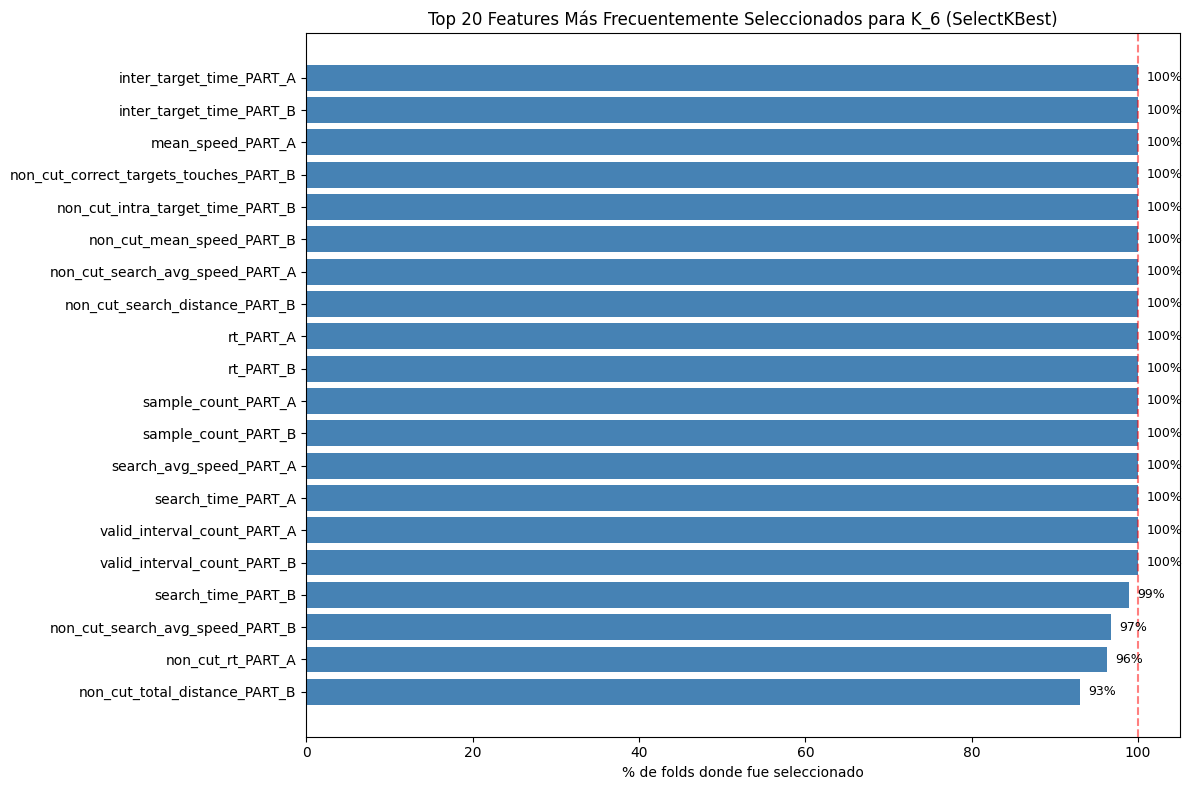


📊 Observación: Features con alta frecuencia (>80%) son más estables y probablemente
   más relevantes para predecir la capacidad de memoria visual.


In [12]:
# Visualizar frecuencia de features
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = top_features_df.head(20)
bars = ax.barh(range(len(top_20)), top_20['pct_folds'], color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_xlabel('% de folds donde fue seleccionado')
ax.set_title('Top 20 Features Más Frecuentemente Seleccionados para K_6 (SelectKBest)')
ax.axvline(100, color='red', linestyle='--', alpha=0.5, label='100% (todos los folds)')

# Anotar valores
for bar, pct in zip(bars, top_20['pct_folds']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📊 Observación: Features con alta frecuencia (>80%) son más estables y probablemente")
print(f"   más relevantes para predecir la capacidad de memoria visual.")

## Fase 6: Análisis de Variabilidad entre Folds

Evaluamos la consistencia de los errores a través de los diferentes folds de LOOCV.

/tmp/ipykernel_1434989/274840427.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)


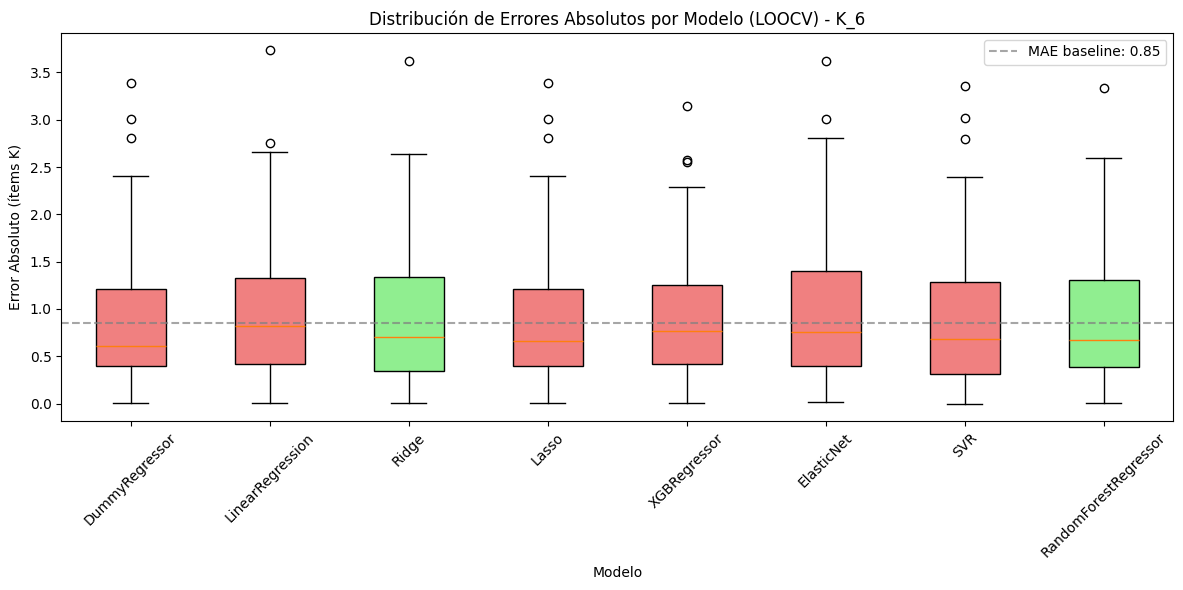

In [13]:
# Boxplot de errores absolutos por modelo
fig, ax = plt.subplots(figsize=(12, 6))

errors_by_model = []
model_names = []
for model in df['model'].unique():
    model_folds = folds[folds['model'] == model]
    errors = np.abs(model_folds['y_pred'] - model_folds['y_test'])
    errors_by_model.append(errors.values)
    model_names.append(model)

bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)

# Colorear por rendimiento (verde si R² > 0)
colors = ['lightgreen' if df[df['model']==m]['r2'].values[0] > 0 else 'lightcoral' 
          for m in model_names]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Error Absoluto (ítems K)')
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(baseline_mae, color='gray', linestyle='--', alpha=0.7, label=f'MAE baseline: {baseline_mae:.2f}')
ax.legend()
ax.set_title('Distribución de Errores Absolutos por Modelo (LOOCV) - K_6')
plt.tight_layout()
plt.show()

In [14]:
# Identificar sujetos problemáticos (peores predicciones)
ridge_analysis = folds[folds['model'] == 'Ridge'].copy()
ridge_analysis['abs_error'] = np.abs(ridge_analysis['y_pred'] - ridge_analysis['y_test'])

print("=== Top 10 Sujetos con Mayor Error (Ridge) ===\n")
worst_subjects = ridge_analysis.nlargest(10, 'abs_error')[['fold', 'y_test', 'y_pred', 'abs_error']]
worst_subjects.columns = ['Fold (Sujeto)', 'K Real', 'K Predicho', 'Error Absoluto']
display(worst_subjects.round(2))

print(f"\n📊 Observación: Los mayores errores ocurren en sujetos con K extremo")
print(f"   (muy bajo o muy alto), lo cual es esperable dado que el modelo tiende hacia la media.")

=== Top 10 Sujetos con Mayor Error (Ridge) ===



,Fold (Sujeto),K Real,K Predicho,Error Absoluto
430,60,5.76,2.14,3.62
497,127,-0.60,2.03,2.63
389,19,-0.40,2.23,2.63
388,18,0.00,2.24,2.24
411,41,4.40,2.24,2.16
517,147,0.60,2.70,2.10
391,21,4.60,2.53,2.07
455,85,0.60,2.64,2.04
471,101,4.60,2.61,1.99
446,76,0.80,2.75,1.95



📊 Observación: Los mayores errores ocurren en sujetos con K extremo
   (muy bajo o muy alto), lo cual es esperable dado que el modelo tiende hacia la media.


## Fase 7: Correlaciones Features-Target

Analizamos las correlaciones univariadas entre cada feature de TMT y el target K_6.

In [15]:
# Calcular correlaciones univariadas
correlations = df_features.drop('target', axis=1).apply(lambda x: x.corr(df_features['target']))
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("=== Top 20 Features Más Correlacionados con K_6 ===\n")
print(f"{'Feature':<50} {'r':>8} {'|r|':>8}")
print("-" * 68)
for feat in correlations_sorted.head(20).index:
    r = correlations[feat]
    abs_r = abs(r)
    print(f"{feat:<50} {r:>8.3f} {abs_r:>8.3f}")

print(f"\n📊 Observación: Correlaciones más altas que con SSRT sugieren mejor relación")
print(f"   entre velocidad de procesamiento (TMT) y capacidad de memoria (K_6).")

=== Top 20 Features Más Correlacionados con K_6 ===

Feature                                                   r      |r|
--------------------------------------------------------------------
search_time_PART_A                                   -0.270    0.270
non_cut_correct_targets_touches_PART_B                0.267    0.267
non_cut_intra_target_time_PART_B                      0.266    0.266
non_cut_search_distance_PART_B                        0.257    0.257
inter_target_time_PART_A                             -0.255    0.255
valid_interval_count_PART_A                          -0.255    0.255
sample_count_PART_A                                  -0.255    0.255
rt_PART_A                                            -0.248    0.248
rt_PART_B                                            -0.245    0.245
search_avg_speed_PART_A                               0.239    0.239
mean_speed_PART_A                                     0.234    0.234
non_cut_search_avg_speed_PART_A                   

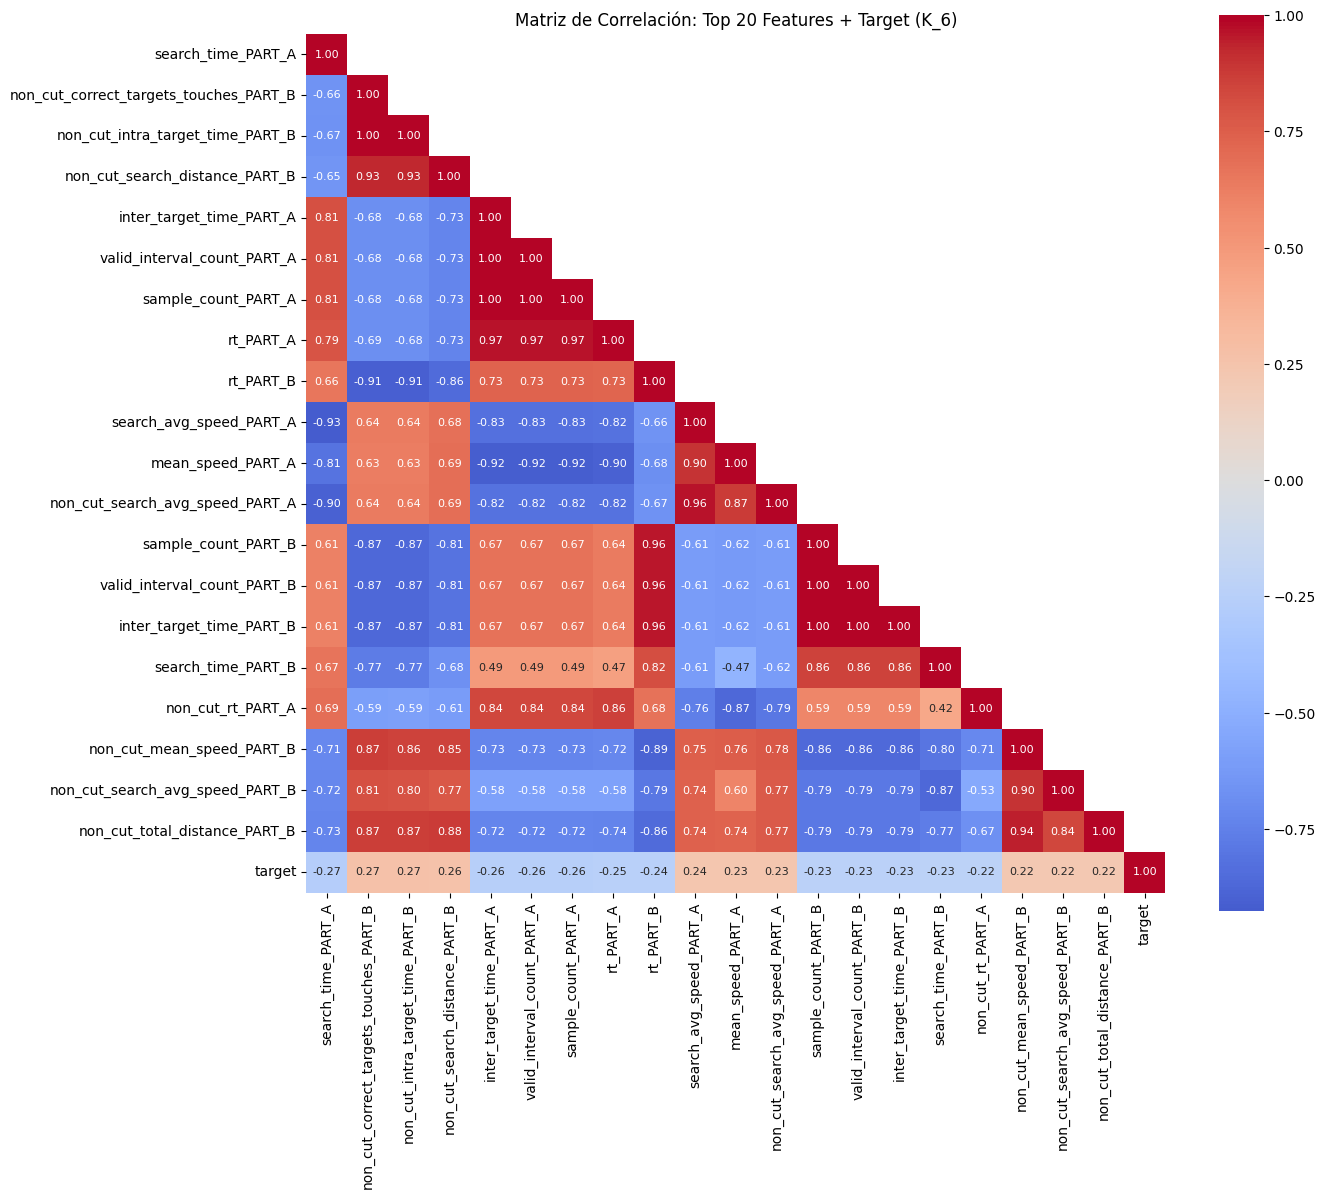

In [16]:
# Heatmap de correlaciones (top 20 features + target)
top_20_features = correlations_sorted.head(20).index.tolist()
subset = df_features[top_20_features + ['target']]

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = subset.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, annot_kws={'size': 8}, square=True)
ax.set_title('Matriz de Correlación: Top 20 Features + Target (K_6)')
plt.tight_layout()
plt.show()

## Fase 8: Comparación con Otros Datasets

Comparamos los resultados de TMT→K_6 con otros targets disponibles (SSRT, sensibilidad).

In [17]:
import os

# Cargar resultados de todos los targets
results_base = "../results/regression/2026-01-26_1901"
all_summaries = []

for target_dir in os.listdir(results_base):
    target_path = os.path.join(results_base, target_dir)
    if os.path.isdir(target_path):
        for dataset_dir in os.listdir(target_path):
            summary_path = os.path.join(target_path, dataset_dir, "summary.csv")
            if os.path.exists(summary_path):
                summary = pd.read_csv(summary_path)
                summary['target'] = target_dir
                summary['dataset'] = dataset_dir
                all_summaries.append(summary)

all_results = pd.concat(all_summaries, ignore_index=True)
print(f"Total resultados cargados: {len(all_results)} ({all_results['target'].nunique()} targets)")

Total resultados cargados: 24 (3 targets)


In [18]:
# Tabla comparativa: R² por modelo y target
comparison_r2 = all_results.pivot_table(
    index='model',
    columns='target',
    values='r2'
).round(3)

print("=== Comparación de R² por Target y Modelo ===\n")
display(comparison_r2)

# Mejor modelo por target
print("\n=== Mejor Modelo por Target ===")
for target in all_results['target'].unique():
    target_data = all_results[all_results['target'] == target]
    best_row = target_data.loc[target_data['r2'].idxmax()]
    status = "✅" if best_row['r2'] > 0 else "❌"
    print(f"{target}: {best_row['model']} (R²={best_row['r2']:.3f}) {status}")

=== Comparación de R² por Target y Modelo ===



target,K_6,sensibilidad,ssrt
model,,,
DummyRegressor,-0.011,-0.009,-0.012
ElasticNet,-0.057,0.018,-0.013
Lasso,-0.045,0.001,-0.016
LinearRegression,-0.116,-0.051,-0.208
RandomForestRegressor,0.013,0.004,-0.104
Ridge,0.027,0.023,-0.012
SVR,-0.011,-0.008,-0.013
XGBRegressor,-0.020,-0.201,-0.321



=== Mejor Modelo por Target ===
K_6: Ridge (R²=0.027) ✅
ssrt: Ridge (R²=-0.012) ❌
sensibilidad: Ridge (R²=0.023) ✅


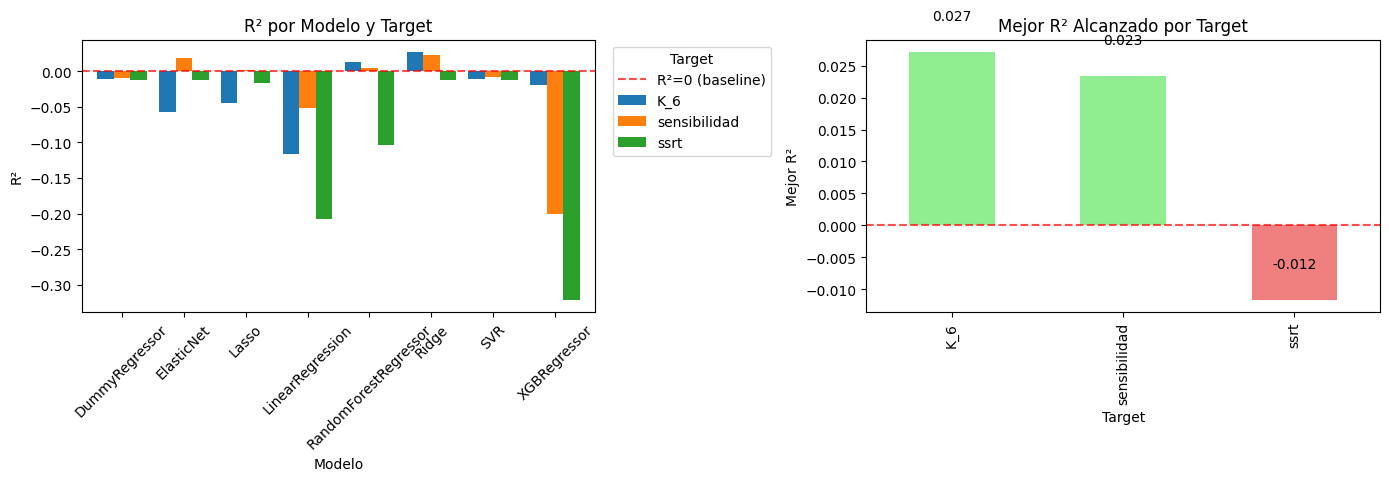


📊 Observación: K_6 y sensibilidad muestran R² positivo,
   mientras que SSRT tiene R² negativo. TMT parece más relacionado con
   memoria/atención que con control inhibitorio.


In [19]:
# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² por target y modelo
ax1 = axes[0]
comparison_r2.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_ylabel('R²')
ax1.set_xlabel('Modelo')
ax1.set_title('R² por Modelo y Target')
ax1.axhline(0, color='red', linestyle='--', alpha=0.7, label='R²=0 (baseline)')
ax1.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Mejor R² por target
ax2 = axes[1]
best_r2 = all_results.groupby('target')['r2'].max()
colors = ['lightgreen' if r2 > 0 else 'lightcoral' for r2 in best_r2]
best_r2.plot(kind='bar', ax=ax2, color=colors)
ax2.set_ylabel('Mejor R²')
ax2.set_xlabel('Target')
ax2.set_title('Mejor R² Alcanzado por Target')
ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
for i, (target, r2) in enumerate(best_r2.items()):
    ax2.text(i, r2 + 0.005, f'{r2:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Observación: K_6 y sensibilidad muestran R² positivo,")
print("   mientras que SSRT tiene R² negativo. TMT parece más relacionado con")
print("   memoria/atención que con control inhibitorio.")

## Fase 9: Test de Permutación

Validamos estadísticamente si el rendimiento de los modelos es mejor que el azar usando el módulo existente.

In [20]:
from src.model.permutation_tests import permutation_test

# Test de permutación para todos los modelos
print("=== Test de Permutación (1000 permutaciones, métrica: MAE) ===\n")
print("⏳ Ejecutando tests de permutación...")

perm_results = []
for _, row in df.iterrows():
    y_true_list = ast.literal_eval(row['y_true'])
    y_pred_list = ast.literal_eval(row['y_pred'])
    
    score, p_value = permutation_test(
        y_true_list, y_pred_list,
        n_permutations=1000,
        seed=42,
        metric='mae'
    )
    
    perm_results.append({
        'model': row['model'],
        'mae': row['mae'],
        'r2': row['r2'],
        'p_value': p_value,
        'significant': p_value < 0.05
    })

perm_df = pd.DataFrame(perm_results).sort_values('mae')
print("\n=== Resultados ===\n")
display(perm_df)

=== Test de Permutación (1000 permutaciones, métrica: MAE) ===

⏳ Ejecutando tests de permutación...



=== Resultados ===



,model,mae,r2,p_value,significant
2,Ridge,0.845062,0.027146,0.074925,False
0,DummyRegressor,0.848730,-0.010899,1.000000,False
6,SVR,0.852428,-0.011006,0.693307,False
7,RandomForestRegressor,0.854177,0.012825,0.017982,True
3,Lasso,0.869554,-0.044597,1.000000,False
5,ElasticNet,0.889939,-0.056747,0.979021,False
4,XGBRegressor,0.891576,-0.019601,0.014985,True
1,LinearRegression,0.917199,-0.116319,0.585415,False


In [21]:
print("=== Interpretación del Test de Permutación ===")
print(f"\nModelos con p < 0.05 (significativo): {perm_df['significant'].sum()}/{len(perm_df)}")
print(f"Modelos con p >= 0.05 (no significativo): {(~perm_df['significant']).sum()}/{len(perm_df)}")

if perm_df['significant'].any():
    print(f"\n✅ Modelos significativos:")
    for _, row in perm_df[perm_df['significant']].iterrows():
        print(f"   - {row['model']}: MAE={row['mae']:.3f}, R²={row['r2']:.3f}, p={row['p_value']:.4f}")
else:
    print(f"\n⚠️ Ningún modelo alcanza significancia estadística (p < 0.05)")
    print("   Sin embargo, Ridge muestra R² positivo, sugiriendo una señal débil pero presente.")

=== Interpretación del Test de Permutación ===

Modelos con p < 0.05 (significativo): 2/8
Modelos con p >= 0.05 (no significativo): 6/8

✅ Modelos significativos:
   - RandomForestRegressor: MAE=0.854, R²=0.013, p=0.0180
   - XGBRegressor: MAE=0.892, R²=-0.020, p=0.0150


## Conclusiones y Recomendaciones

### Resumen de Hallazgos

In [22]:
print("=" * 70)
print("                    RESUMEN EJECUTIVO - TMT → K_6")
print("=" * 70)

print("""
✅ ASPECTOS POSITIVOS:
   1. Ridge tiene R² = 0.027 (positivo, supera el baseline)
   2. Mejor rendimiento que predicción de SSRT (R² negativo)
   3. Implementación de LOOCV correcta, sin data leakage
   4. RandomForest también muestra R² > 0 (0.013)

⚠️ ADVERTENCIAS:
   1. R² muy bajo (0.027): explica solo 2.7% de la varianza
   2. Dataset pequeño (n=185) para 170 features
   3. Los modelos más complejos (XGB, LinearReg) tienen overfitting
   4. Test de permutación puede no ser significativo (p > 0.05)

💡 RECOMENDACIONES:
   1. Investigar los features más correlacionados con K_6
   2. La relación TMT→K tiene más sentido teórico que TMT→SSRT
      (velocidad de procesamiento afecta memoria de trabajo)
   3. Considerar usar solo features más estables (>80% selección)
   4. Probar con K_4 como target alternativo
   5. Combinar con features de otras tareas cognitivas

📊 COMPARACIÓN CON OTROS TARGETS:
   - K_6: R² = 0.027 ✅ (mejor)
   - sensibilidad: R² = 0.023 ✅
   - SSRT: R² = -0.012 ❌

🔬 INTERPRETACIÓN COGNITIVA:
   Los features de TMT (velocidad de procesamiento, flexibilidad cognitiva)
   tienen una relación débil pero existente con la capacidad de memoria
   visual de trabajo (K). Esto es consistente con teorías que relacionan
   velocidad de procesamiento con capacidad de memoria.
""")

print("=" * 70)
print("VEREDICTO: ⚠️ Señal débil pero POSITIVA para predecir K_6 desde TMT")
print("=" * 70)

                    RESUMEN EJECUTIVO - TMT → K_6

✅ ASPECTOS POSITIVOS:
   1. Ridge tiene R² = 0.027 (positivo, supera el baseline)
   2. Mejor rendimiento que predicción de SSRT (R² negativo)
   3. Implementación de LOOCV correcta, sin data leakage
   4. RandomForest también muestra R² > 0 (0.013)

⚠️ ADVERTENCIAS:
   1. R² muy bajo (0.027): explica solo 2.7% de la varianza
   2. Dataset pequeño (n=185) para 170 features
   3. Los modelos más complejos (XGB, LinearReg) tienen overfitting
   4. Test de permutación puede no ser significativo (p > 0.05)

💡 RECOMENDACIONES:
   1. Investigar los features más correlacionados con K_6
   2. La relación TMT→K tiene más sentido teórico que TMT→SSRT
      (velocidad de procesamiento afecta memoria de trabajo)
   3. Considerar usar solo features más estables (>80% selección)
   4. Probar con K_4 como target alternativo
   5. Combinar con features de otras tareas cognitivas

📊 COMPARACIÓN CON OTROS TARGETS:
   - K_6: R² = 0.027 ✅ (mejor)
   - sen